In [11]:
import pandas as pd
import numpy as nb



pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotly.graph_objects as go
import plotly.offline as py
import plotly.figure_factory as ff
import warnings
warnings.filterwarnings('ignore')

In [9]:
!pip install plotly



   ---------------------------------------- 0.0/19.1 MB ? eta -:--:--
    --------------------------------------- 0.3/19.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/19.1 MB 1.9 MB/s eta 0:00:10
   - -------------------------------------- 0.8/19.1 MB 1.5 MB/s eta 0:00:13
   -- ------------------------------------- 1.3/19.1 MB 1.8 MB/s eta 0:00:11
   --- ------------------------------------ 1.8/19.1 MB 1.9 MB/s eta 0:00:10
   ---- ----------------------------------- 2.4/19.1 MB 1.9 MB/s eta 0:00:09
   ------ --------------------------------- 2.9/19.1 MB 2.1 MB/s eta 0:00:08
   ------- -------------------------------- 3.7/19.1 MB 2.3 MB/s eta 0:00:07
   -------- ------------------------------- 4.2/19.1 MB 2.4 MB/s eta 0:00:07
   --------- ------------------------------ 4.7/19.1 MB 2.4 MB/s eta 0:00:07
   ----------- ---------------------------- 5.2/19.1 MB 2.4 MB/s eta 0:00:06
   ------------ --------------------------- 5.8/19.1 MB 2.3 MB/s eta 0:00:06
   ----------

In [13]:
data= pd.read_csv("C:/Users/akrit/Downloads/data.csv")
data.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [3]:
data.head(4)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN


In [4]:
frame= pd.DataFrame({"null value":data.isnull().sum(),"percentage of  null value":(data.isnull().sum())/(data.shape[0])*100})
frame

,null value,percentage of null value
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


In [5]:


trace = go.Bar(
    x=frame.index,
    y=frame['null value'],
    opacity=0.8,
    marker=dict(
        color='lightgrey',
        line=dict(color='#000000', width=1.5)
    )
)

layout = dict(title='Missing Value')

fig = dict(data=[trace], layout=layout)

py.iplot(fig)


# msno.bar(data)
# plt.show()

In [6]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [7]:

data.drop(['Unnamed: 32'],inplace=True,axis=1)
data.drop(['id'],inplace=True,axis=1)


In [8]:
mapp={'M':1,'B':0}
data['diagnosis']=data['diagnosis'].map(mapp)

In [9]:
data['radius_mean'].max()

28.11

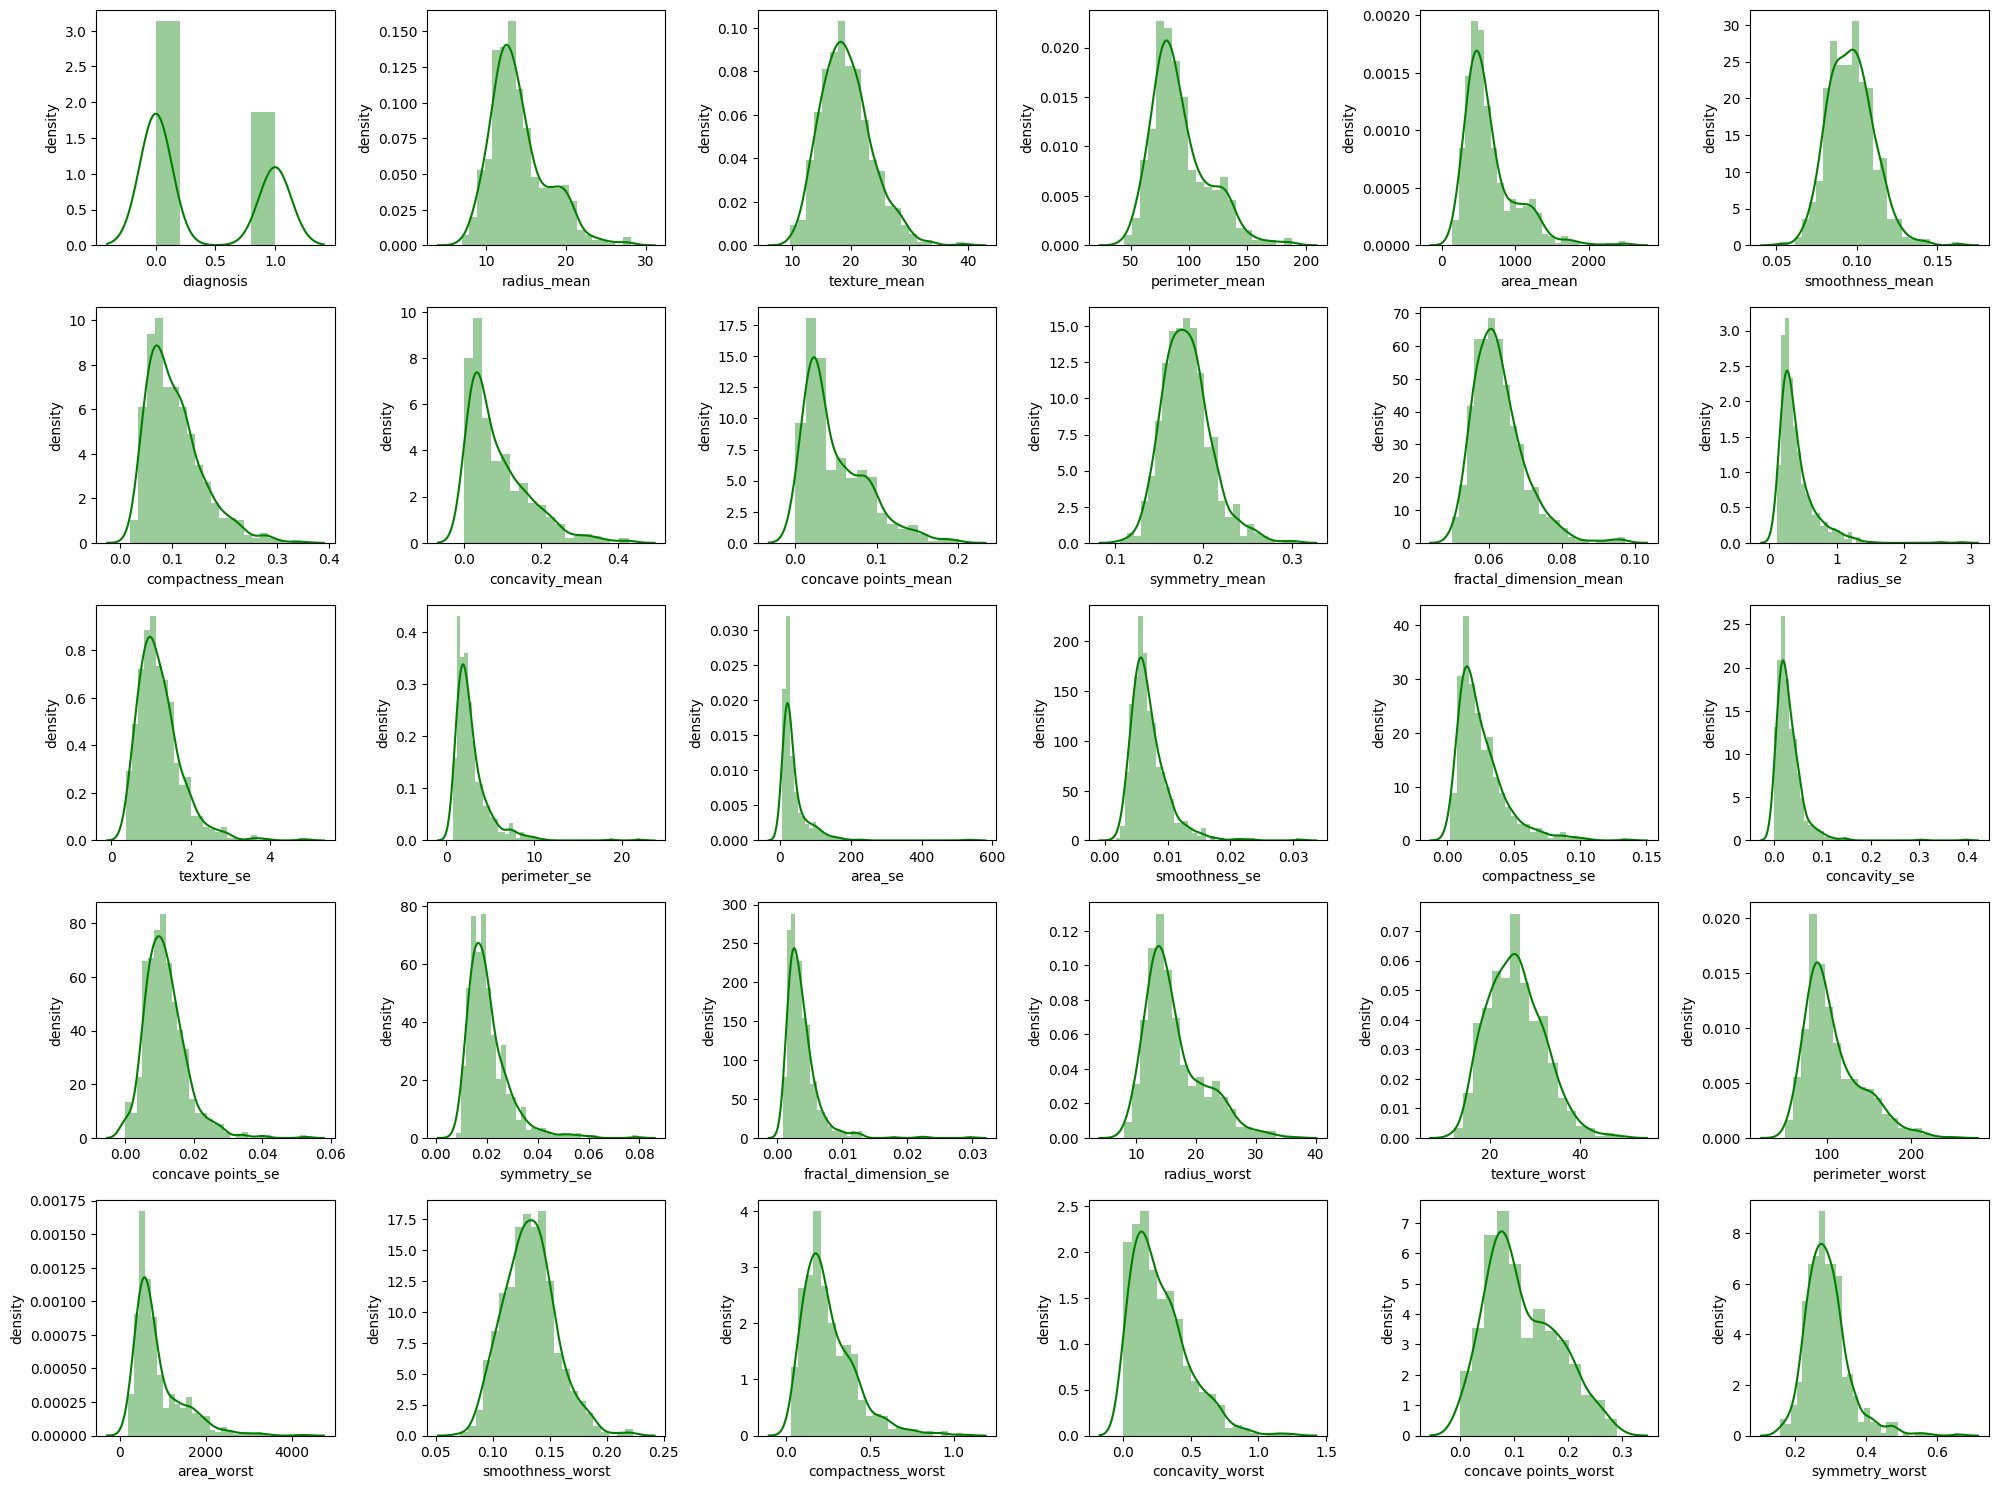

In [10]:
plt.figure(figsize=(20,15))
plotnumber=1

for columns in data:
    if plotnumber <= 30:
        ax= plt.subplot(5,6,plotnumber)
        
        
        sns.distplot(data[columns],ax=ax,color='green')
        # sns.histplot(data[columns],kde=True,ax=ax,color='green')
        
        plt.xlabel(columns)
        plt.ylabel('density')
        plotnumber +=1
    
    
plt.tight_layout()    
plt.show()

In [11]:
for col in data:
    data[col]=np.log(data[col]+1)

In [12]:
data.head(3)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.693147,2.943913,2.431857,4.818667,6.909753,0.111899,0.244983,0.262441,0.137237,0.216642,0.075766,0.739554,0.644639,2.260617,5.039547,0.006379,0.047875,0.052336,0.015745,0.029588,0.006174,3.272606,2.908539,5.223594,7.610853,0.150315,0.510185,0.537604,0.235388,0.378505,0.112346
1,0.693147,3.071303,2.932260,4.897093,7.190676,0.081340,0.075701,0.083330,0.067818,0.166531,0.055122,0.434053,0.550373,1.481150,4.318554,0.005211,0.012995,0.018429,0.013311,0.013794,0.003526,3.257712,3.194993,5.073923,7.579168,0.116716,0.171092,0.216401,0.170586,0.242946,0.085278
2,0.693147,3.029650,3.102342,4.875197,7.093405,0.104000,0.148334,0.180153,0.120357,0.188055,0.058259,0.557098,0.580482,1.720084,4.554193,0.006131,0.039278,0.037604,0.020371,0.022251,0.004561,3.201526,3.278276,5.033701,7.444249,0.134880,0.353821,0.371839,0.217528,0.308440,0.083955


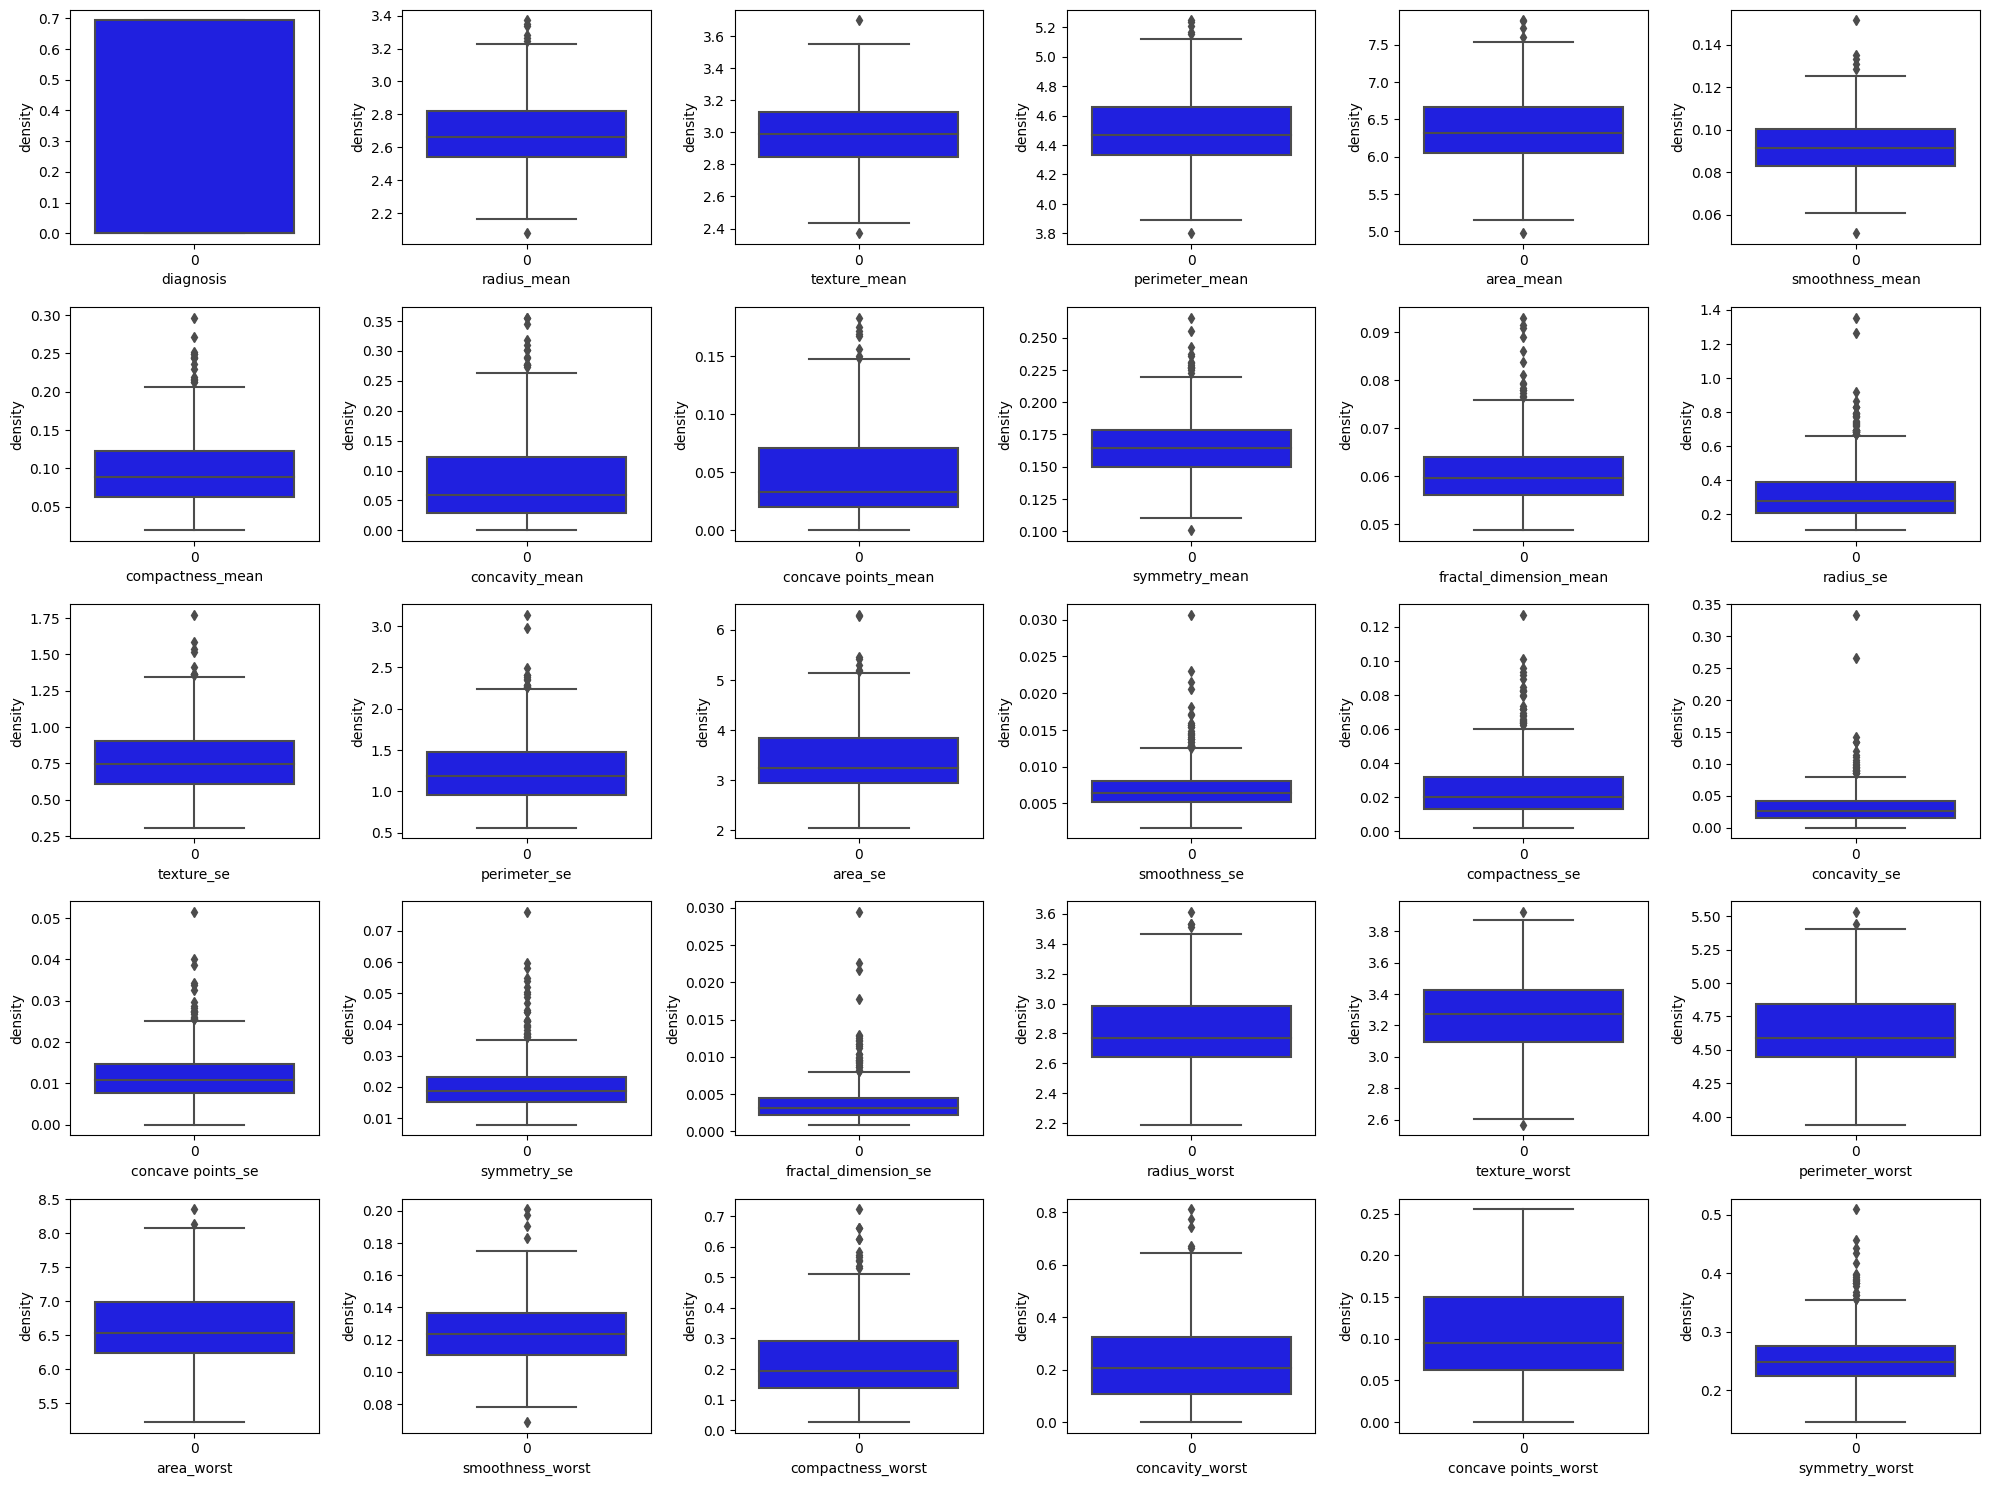

In [13]:
plt.figure(figsize=(20,15))
plotnumber=1

for columns in data:
    if plotnumber <= 30:
        ax= plt.subplot(5,6,plotnumber)
        
        
        sns.boxplot(data[columns],ax=ax,color='blue')
      
        
        plt.xlabel(columns)
        plt.ylabel('density')
        plotnumber +=1
    
    
plt.tight_layout()    
plt.show()

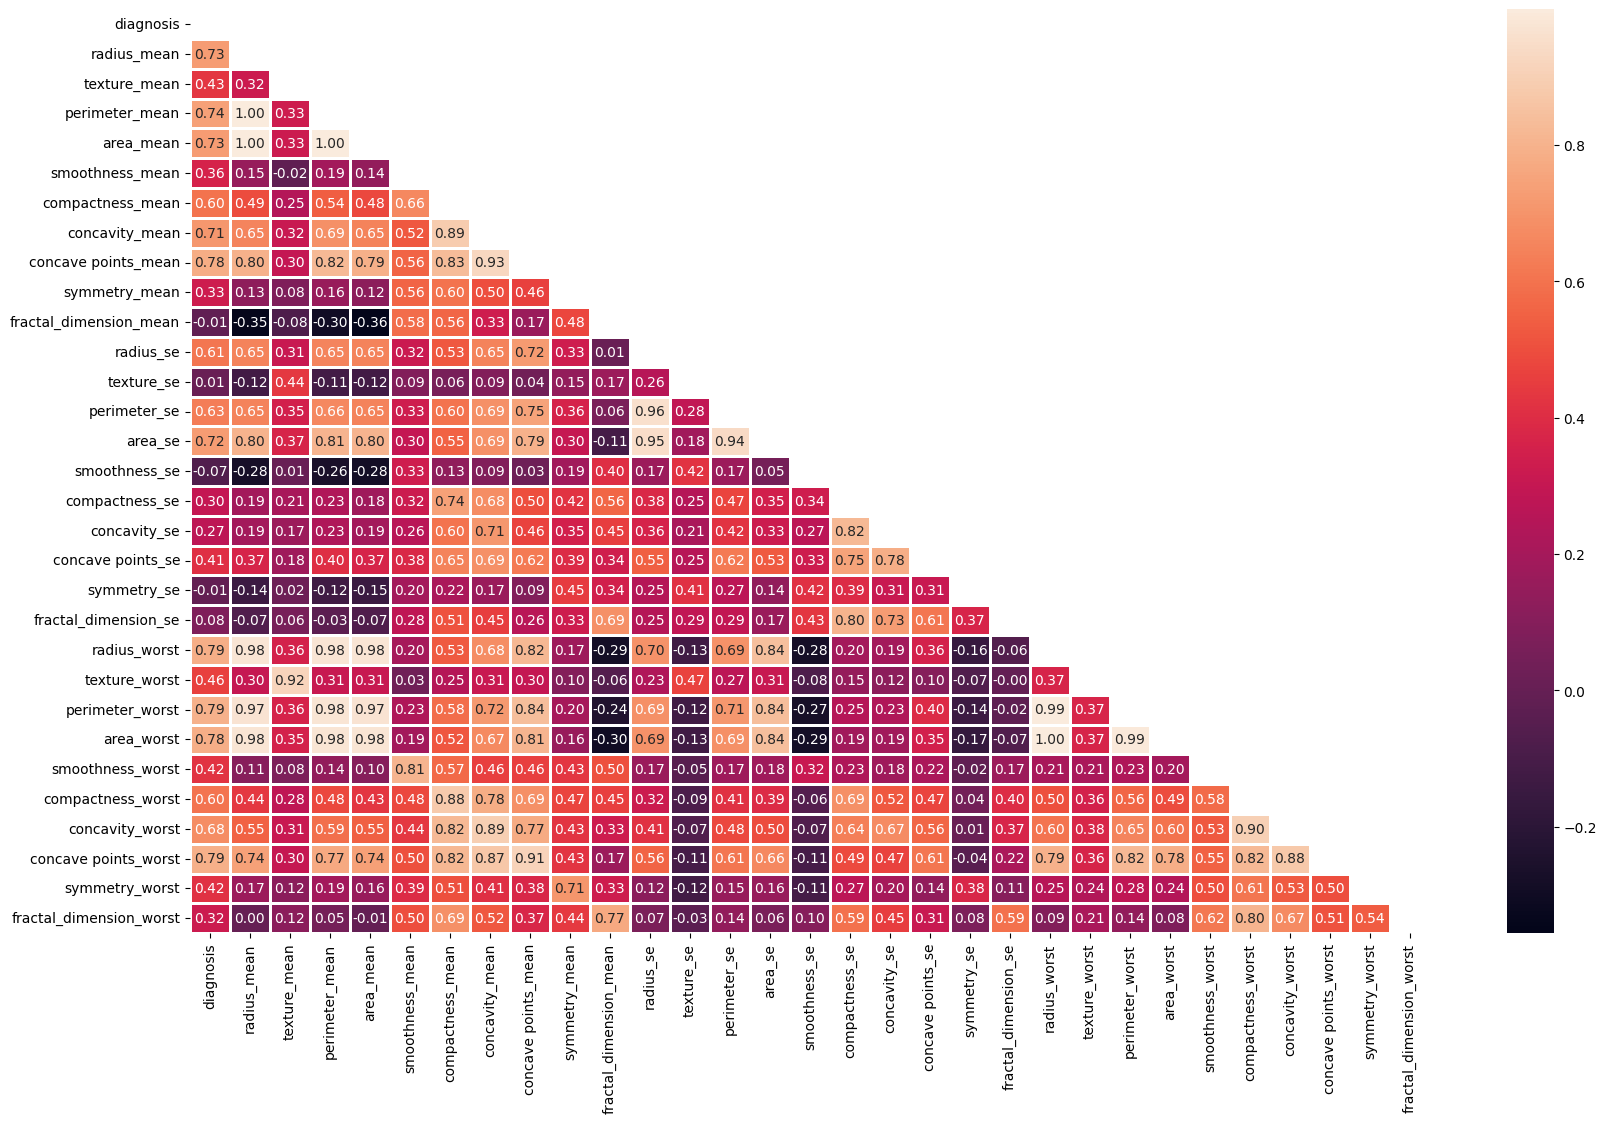

In [14]:
plt.figure(figsize = (20, 12))
corr= data.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, linewidths = 1, annot = True,fmt=".2f")
plt.show()

## target distribution

In [15]:
f= (data["diagnosis"] ==0)
B= data[f]
M=data[~f]

In [16]:

# B
# M

M.shape
data.shape

(569, 31)

In [17]:


trace = go.Bar(x=[len(M), len(B)], y=['malignant', 'benign'],
               orientation='h',
               opacity=0.8,
               marker=dict(
                   color=['gold', 'blue'],
                   line=dict(color='#000000', width=1.5)
               )
              )

layout = dict(title='Count of Diagnosis')
fig = dict(data = [trace], layout=layout)
py.iplot(fig)

# -------------------------------------------------------------------------------------------------------------------------------------

malignant_percentage = (M.shape[0] / data.shape[0]) * 100
benign_percentage = (B.shape[0] / data.shape[0]) * 100


df = pd.DataFrame({"malignant": [malignant_percentage], "benign": [benign_percentage]})
df

trace = go.Pie(labels=['benign', 'malignant'],
               values=[df['benign'][0], df['malignant'][0]],
               textfont=dict(size=20),
               opacity=0.8,
               marker=dict(colors=['lightskyblue', 'gold'], 
                           line=dict(color='#000000', width=1.5))
              )

layout = dict(title='Distribution of diagnosis variable')
fig = dict(data=[trace], layout=layout)
py.iplot(fig)




In [18]:
def plot(column,size):
    one=M[column]
    two=B[column]
    data=[one,two]
    
    glabel=['malignant','benign']
    col=["blue","red"]
    
    fig=ff.create_distplot(data,glabel,colors=col,show_hist=True, bin_size = size, curve_type='kde')
    fig['layout'].update(title = column)

    py.iplot(fig)
    
    


In [19]:
plot('radius_mean',.5)
# plot('texture_mean', .5)
# plot('perimeter_mean', .5)
# plot('area_mean', .5)
# plot('smoothness_mean', .10)
# plot('compactness_mean', .5)
# plot('concavity_mean', .5)
# plot('concave points_mean', .5)
# plot('symmetry_mean', .10)
# plot('fractal_dimension_mean', .10)


In [20]:
def plot_feat1_feat2(feat1, feat2) :  
    trace0 = go.Scatter(
        x = M[feat1],
        y = M[feat2],
        name = 'malignant',
        mode = 'markers', 
        marker = dict(color = '#FFD700',
            line = dict(
                width = 1)))

    trace1 = go.Scatter(
        x = B[feat1],
        y = B[feat2],
        name = 'benign',
        mode = 'markers',
        marker = dict(color = '#7EC0EE',
            line = dict(
                width = 1)))

    layout = dict(title = feat1 +" "+"vs"+" "+ feat2,
                  yaxis = dict(title = feat2,zeroline = False),
                  xaxis = dict(title = feat1, zeroline = False)
                 )

    plots = [trace0, trace1]

    fig = dict(data = plots, layout=layout)
    py.iplot(fig)
        
    

In [21]:
plot_feat1_feat2('perimeter_mean','radius_worst')
# plot_feat1_feat2('area_mean','radius_worst')
# plot_feat1_feat2('texture_mean','texture_worst')
# plot_feat1_feat2('area_worst','radius_worst')


# # uncorrelated features
# plot_feat1_feat2('smoothness_mean','texture_mean')
# plot_feat1_feat2('radius_mean','fractal_dimension_worst')
# plot_feat1_feat2('texture_mean','symmetry_mean')
# plot_feat1_feat2('texture_mean','symmetry_se')

In [22]:
corr_matrix = data.corr().abs() 

mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
tri_df = corr_matrix.mask(mask)

to_drop = [x for x in tri_df.columns if any(tri_df[x] > 0.92)]

df = data.drop(to_drop, axis = 1)

print(f"The reduced dataframe has {df.shape[1]} columns.")

The reduced dataframe has 23 columns.


In [23]:
data.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

# model


In [24]:
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

In [59]:

X= data.drop('diagnosis',axis=1)
x=preprocessing.StandardScaler().fit(X).transform(X)



In [70]:
DATA=pd.read_csv("C:/Users/akrit/Downloads/data.csv")
Y=DATA["diagnosis"]
Y=Y.replace({"M":1,"B":0})
Y

0      1
1      1
2      1
3      1
4      1
5      1
6      1
7      1
8      1
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     1
17     1
18     1
19     0
20     0
21     0
22     1
23     1
24     1
25     1
26     1
27     1
28     1
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     0
38     1
39     1
40     1
41     1
42     1
43     1
44     1
45     1
46     0
47     1
48     0
49     0
50     0
51     0
52     0
53     1
54     1
55     0
56     1
57     1
58     0
59     0
60     0
61     0
62     1
63     0
64     1
65     1
66     0
67     0
68     0
69     0
70     1
71     0
72     1
73     1
74     0
75     1
76     0
77     1
78     1
79     0
80     0
81     0
82     1
83     1
84     0
85     1
86     1
87     1
88     0
89     0
90     0
91     1
92     0
93     0
94     1
95     1
96     0
97     0
98     0
99     1
100    1
101    0
102    0
103    0
104    0
105    1
106    0
107    0
108    1
109    0
110    0
1

In [74]:
if isinstance(Y, np.ndarray):
    print("already an array ")
    
    
else:
    Y=np.array(Y)


already an array 


In [73]:
Y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [77]:
x

array([[ 1.13802997, -2.65895658,  1.28162791, ...,  2.20731825,
         2.68261447,  1.939736  ],
       [ 1.71178285, -0.267352  ,  1.59772138, ...,  1.09501329,
        -0.22874045,  0.29250113],
       [ 1.52418308,  0.54553229,  1.50947042, ...,  1.90074915,
         1.17785357,  0.21197892],
       ...,
       [ 0.7956741 ,  1.82500895,  0.77954796, ...,  0.44309312,
        -1.14409894, -0.31515743],
       [ 1.71804258,  2.0261564 ,  1.80881986, ...,  2.20189154,
         1.91294028,  2.21648928],
       [-2.34669314,  1.20462474, -2.46059019, ..., -1.83304534,
        -0.02588339, -0.75757376]])

## logistic regression

In [78]:
reg= LogisticRegression()
parameter = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_cv= GridSearchCV(reg,parameter,cv=10)

log_cv.fit(X_train,y_train)
print(log_cv.best_params_)
print(log_cv.best_score_)


{'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.9737681159420291


In [82]:
accuracy = log_cv.score(X_test,y_test)


accuracy on test data: 0.9736842105263158


In [86]:
y_pre=log_cv.predict(X_test)

In [94]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y,y_predict):
    

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    # ax.xaxis.set_ticklabels(['non-cancerous', 'cancer']); ax.yaxis.set_ticklabels(['non-cancerous', 'cancer']) 
    plt.show() 

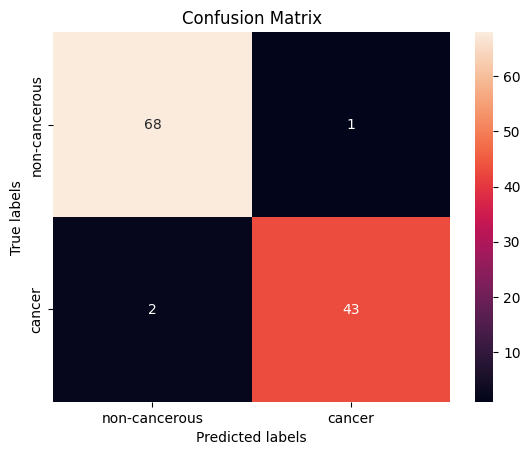

In [95]:
plot_confusion_matrix(y_test,y_pre)

In [93]:


from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

confusion= confusion_matrix(y_test,y_pre)
clf_report= classification_report(y_test,y_pre)




print("the accuracy score is ",accuracy)
print("the confusion matrix is \n",confusion)
print("the classification report is \n", clf_report)


the accuracy score is  0.9736842105263158
the confusion matrix is 
 [[68  1]
 [ 2 43]]
the classification report is 
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        69
           1       0.98      0.96      0.97        45

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet

AttributeError: module 'numpy.random' has no attribute 'mtrand'

In [122]:
reg=ElasticNet()
regre= LinearRegression()

In [125]:
param_grid = {
  'alpha': [0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.5, 0.9],
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'positive': [True, False]
}

regre_cv= GridSearchCV(reg,param_grid,cv=20)
regr_cv= GridSearchCV(regre,param_grid,cv=20)

regre_cv.fit(X_test,y_test)
print(regre_cv.best_params_)
print(regre_cv.best_score_)


print(regr_cv.best_score_)

{'alpha': 0.1, 'copy_X': True, 'fit_intercept': True, 'l1_ratio': 0.1, 'positive': True}
0.4782121405399489


AttributeError: 'GridSearchCV' object has no attribute 'best_score_'

In [4]:
d= pd.read_csv("C:/Users/akrit/Downloads/homeprices.csv")

In [6]:
d

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [16]:
sns.regplot(data=d,x="area",y="price", color='green', marker='+')
plt.show()

NameError: name 'sns' is not defined